# RL Market Maker — Feature Engineering for Linear Function Approximation

In [1]:
%pip install yfinance pandas numpy matplotlib tqdm --quiet
import warnings; warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import yfinance as yf
from utils.charts import MarketCharts

tickers = ['BTC-EUR', 'C3M.MI', 'VWCE.DE',]
BENCHMARK_ASSET = 'VWCE.DE'

print(f'Downloading historical data for {tickers}...')
df_prices = yf.download(tickers, start='2015-01-01', end='2024-01-01')['Close']
df_prices = df_prices.dropna()
print('Data loaded successfully! Shape:', df_prices.shape)

df_normalized = (df_prices / df_prices.iloc[0]) * 100

import os; os.makedirs("data", exist_ok=True)
df_normalized.to_csv("data/df_normalized.csv")
print("Saved df_normalized -> data/df_normalized.csv", df_normalized.shape)


[*********************100%***********************]  3 of 3 completed

Data loaded successfully! Shape: (1125, 3)
Saved df_normalized -> data/df_normalized.csv (1125, 3)


## Environment exploration

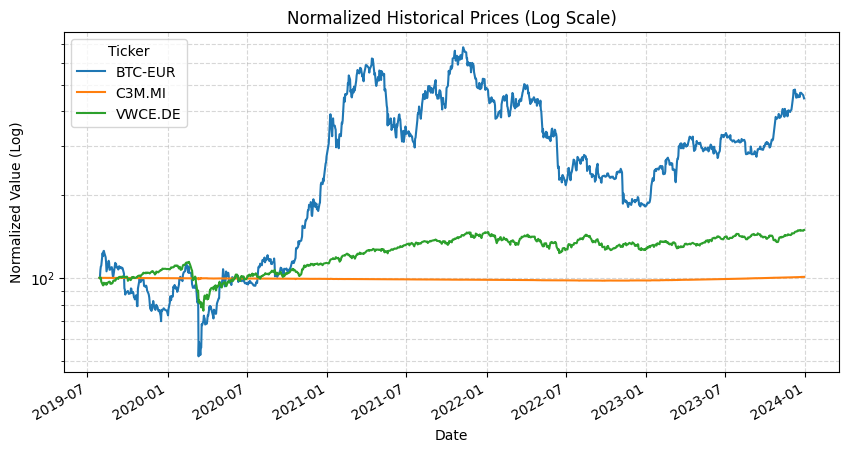

Asset      | Step         | Revenue 1Y   | Volatility 1Y     
--------------------------------------------------------------
BTC-EUR    |     0.2190% |      73.56% |           65.17%
C3M.MI     |     0.0007% |       0.19% |            0.92%
VWCE.DE    |     0.0416% |      11.05% |           17.46%


In [3]:
MarketCharts.plot_normalized_prices(df_normalized)

import numpy as np
returns = df_prices.pct_change().dropna()
mu_values = returns.mean().values
cov_matrix = returns.cov().values  
giorni_finanziari = 252

print(f"{'Asset':<10} | {'Step':<12} | {'Revenue 1Y':<12} | {'Volatility 1Y':<18}")
print("-" * 62)

for i, mu in enumerate(mu_values):
    asset_name = df_prices.columns[i] if hasattr(df_prices, 'columns') else f"Asset {i+1}"
    
    step_pct = mu * 100
    annual_pct = ((1 + mu) ** giorni_finanziari - 1) * 100
    daily_vol = np.sqrt(cov_matrix[i, i])
    annual_vol = daily_vol * np.sqrt(giorni_finanziari) * 100
    
    print(f"{asset_name:<10} | {step_pct:>10.4f}% | {annual_pct:>10.2f}% | {annual_vol:>15.2f}%")

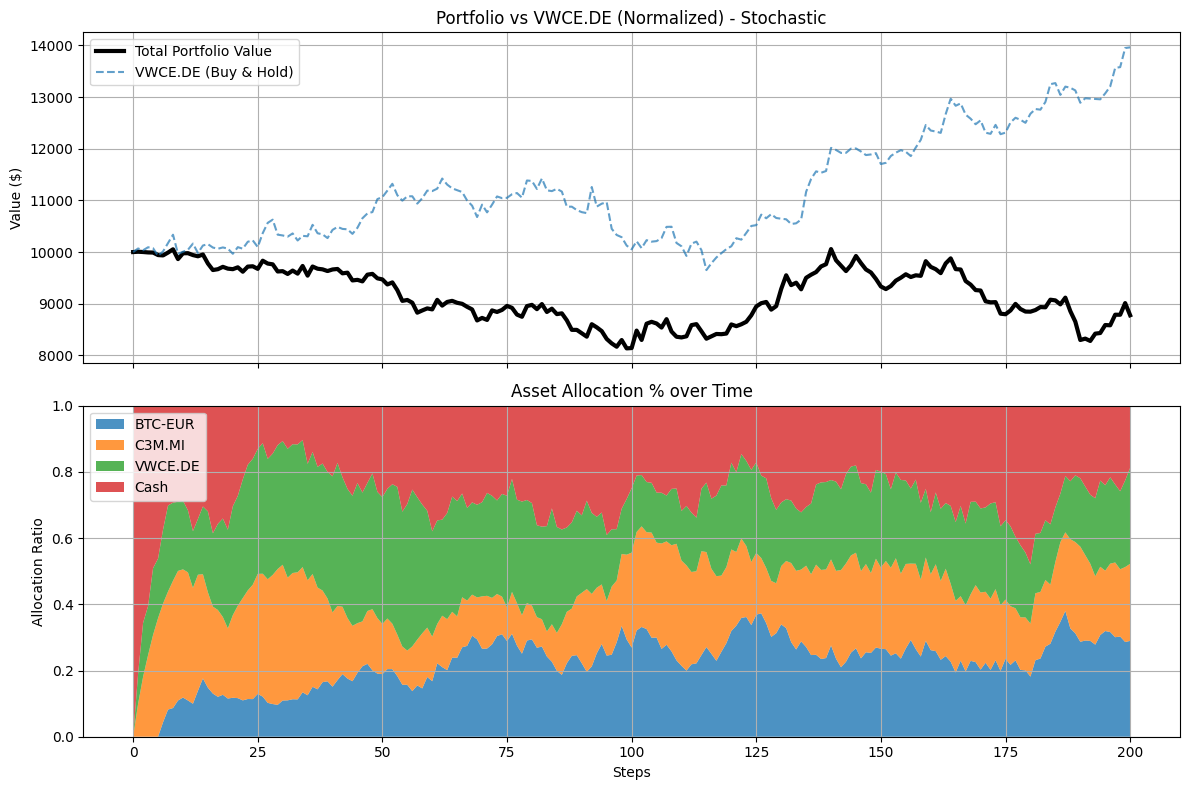

In [4]:
from envs.market import MarketEnv

history_rsi, history_corr = [], []
history_portfolio, history_port_std = [], []
history_prices, history_regime = [], []
history_macd = []

env_hist = MarketEnv(df_prices=df_normalized, stochastic=True, regime_changing=True)
obs, info = env_hist.reset(seed=42)
for step in range(200):
    action = env_hist.action_space.sample()
    obs, reward, terminated, truncated, info = env_hist.step(action)
    history_rsi.append(info['rsi'])
    history_corr.append(info['correlation'])
    history_portfolio.append(info['portfolio_value'])
    history_port_std.append(info['port_std'])
    history_prices.append(info['prices'])
    history_regime.append(info['regime'])
    history_macd.append(info['macd'])
    if step % 10 == 0:
        env_hist.render(benchmark_asset=BENCHMARK_ASSET)
        time.sleep(0.05)
env_hist.render(benchmark_asset=BENCHMARK_ASSET)

# Feauture Exploration

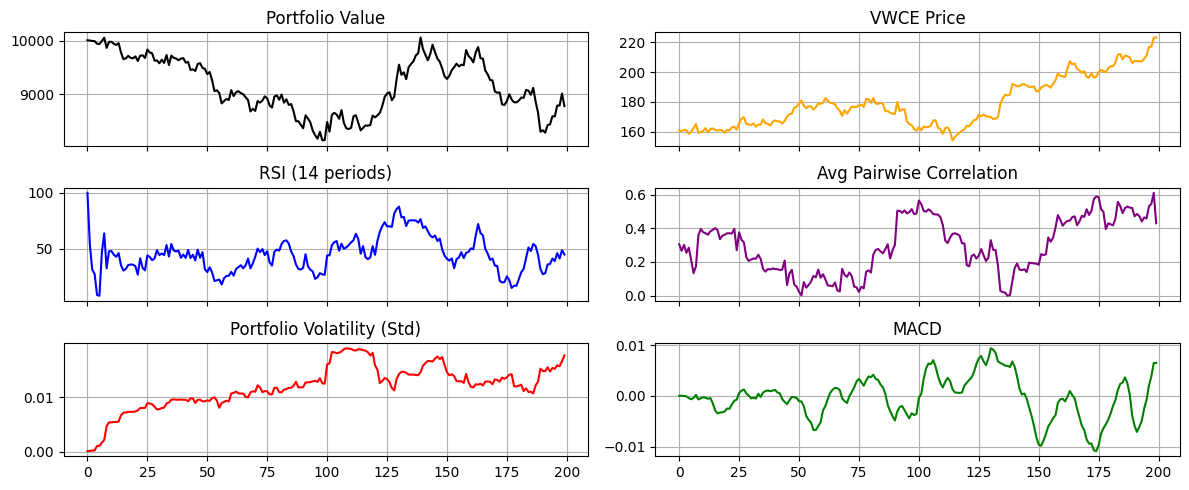

In [5]:
MarketCharts.plot_market_env_history(history_portfolio, history_prices, history_rsi, history_corr, history_port_std, history_macd)

## Calibration of Bounds for every Feauture

In [6]:
def make_env():
    return MarketEnv(df_prices=df_normalized, stochastic=False, regime_changing=False)

def make_env_stochastic():
    return MarketEnv(df_prices=df_normalized, stochastic=True, regime_changing=True)

from utils.calibration import FeatureCalibration
# ---- Feature-range calibration 
FeatureCalibration.calibrate_feature_ranges(make_env_stochastic)


idx  name             min         max          p1         p99
  6  cash          0.0570      1.0000      0.0987      0.5618
  7  rsi           0.0000    100.0000      6.6807     83.4742
  9  vol           0.0000      0.0309      0.0032      0.0271
 10  macd         -0.0174      0.0154     -0.0130      0.0111


## Linear-FA SARSA agent


In [7]:
from agents.linear_sarsa import LinearSARSAAgent
from utils.features import TileCoder, RBFFeatures, PolynomialFeatures
from utils.training import train, evaluate

# ----- Training schedule (kept identical across feature sets) --------
N_EPISODES         = 2000
EVAL_EVERY         = 50
EVAL_EPISODES      = 20
MAX_STEPS_PER_EP   = 250
EVAL_MAX_STEPS     = 250
MASTER_SEED        = 42
NOMINAL_ALPHA      = 0.1

TC_N_TILES   = [5, 5, 5, 5]
TC_N_TILINGS = 4
TC_ALPHA     = NOMINAL_ALPHA / TC_N_TILINGS  # rescale for sparse activations

RBF_N_CENTERS = [4, 4, 4, 4]
RBF_SIGMA     = 0.1
RBF_ALPHA     = NOMINAL_ALPHA

POLY_ALPHA    = 0.0001  # polynomial features need a smaller step size

N_SEEDS = 1  

## Feauture Sets

In [8]:
# ---- Set A: Raw (TileCoder) — prices + cash ----------------------------
feat_setA = TileCoder(
    low=np.array([0, 0, 0, 0]),
    high=np.array([1500, 1500, 1500, 1]),
    n_tiles=[5, 5, 5, 5],
    n_tilings=TC_N_TILINGS,
    feature_indices=[0, 1, 2, 6],
)
print('Set A - Raw (TileCoder), n_features =', feat_setA.n_features)

# ---- Set B: mono (port_std) -------------------------------------------
feat_setB = TileCoder(
    low=np.array([0]),
    high=np.array([0.03]),
    n_tiles=[8],
    n_tilings=TC_N_TILINGS,
    feature_indices=[9],
)
print('Set B - mono (port_std), n_features =', feat_setB.n_features)

# ---- Set C: (MACD, port_std) -----------------------------------------
feat_setC = TileCoder(
    low=np.array([-0.015, 0]),
    high=np.array([0.015, 0.03]),
    n_tiles=[6, 6],
    n_tilings=TC_N_TILINGS,
    feature_indices=[10, 9],
)
print('Set C - (MACD, port_std), n_features =', feat_setC.n_features)

# ---- Set D: (MACD, port_std, RSI) ------------------------------------
feat_setD = TileCoder(
    low=np.array([-0.015, 0, 0]),
    high=np.array([0.015, 0.03, 100]),
    n_tiles=[4, 5, 4],
    n_tilings=TC_N_TILINGS,
    feature_indices=[10, 9, 7],
)
print('Set D - (MACD, port_std, RSI), n_features =', feat_setD.n_features)

# ---- Set E: (avg_corr, RSI, MACD) ------------------------------------
feat_setE = TileCoder(
    low=np.array([-0.5, 0, -0.015]),
    high=np.array([0.75, 100, 0.015]),
    n_tiles=[4, 5, 4],
    n_tilings=TC_N_TILINGS,
    feature_indices=[8, 7, 10],
)
print('Set E - (avg_corr, RSI, MACD), n_features =', feat_setE.n_features)

# ---- Set F: Polynomial (RSI, MACD, port_std) -------------------------
feat_set3 = PolynomialFeatures(
    state_dim=11,
    degree=2,
    feature_indices=[7, 10, 9],  # RSI, MACD, port_std
    low=np.array([0, -0.015, 0]),
    high=np.array([100, 0.015, 0.03]),
)
print('Set F - Polynomial (RSI, MACD, port_std), n_features =', feat_set3.n_features)

# ---- Set G: RBF (MACD, port_std) -------------------------------------
feat_setG = RBFFeatures(
    low=np.array([-0.015, 0]),
    high=np.array([0.015, 0.03]),
    n_centers=[4, 4],
    sigma=RBF_SIGMA,
    normalize=True,
    feature_indices=[10, 9],  # MACD, port_std
)
print('Set G - RBF (MACD, port_std), n_features =', feat_setG.n_features)

# ---- Set H: RBF (port_std, RSI, MACD) --------------------------------
feat_set2 = RBFFeatures(
    low=np.array([0, 0, -0.015]),
    high=np.array([0.03, 100, 0.015]),
    n_centers=[4, 4, 4],
    sigma=RBF_SIGMA,
    normalize=True,
    feature_indices=[9, 7, 10],  # port_std, RSI, MACD
)
print('Set H - RBF (port_std, RSI, MACD), n_features =', feat_set2.n_features)

# ---- Set I: Raw Portfolio Allocation (TileCoder) ---------------------
feat_setI = TileCoder(
    low=np.array([0, 0, 0, 0]),
    high=np.array([1, 1, 1, 1]),
    n_tiles=[5, 5, 5, 5],
    n_tilings=TC_N_TILINGS,
    feature_indices=[3, 4, 5, 6],
)
print('Set I - Raw Portfolio Allocation (TileCoder), n_features =', feat_setI.n_features)

# ---- Set L: Polynomial (asset allocation) ----------------------------
feat_setL = PolynomialFeatures(
    state_dim=11,
    degree=2,
    feature_indices=[3, 4, 5, 6],  # asset allocation
    low=np.array([0, 0, 0, 0]),
    high=np.array([1, 1, 1, 1]),
)
print('Set L - Polynomial (asset allocation), n_features =', feat_setL.n_features)


Set A - Raw (TileCoder), n_features = 2500
Set B - mono (port_std), n_features = 32
Set C - (MACD, port_std), n_features = 144
Set D - (MACD, port_std, RSI), n_features = 320
Set E - (avg_corr, RSI, MACD), n_features = 320
Set F - Polynomial (RSI, MACD, port_std), n_features = 10
Set G - RBF (MACD, port_std), n_features = 16
Set H - RBF (port_std, RSI, MACD), n_features = 64
Set I - Raw Portfolio Allocation (TileCoder), n_features = 2500
Set L - Polynomial (asset allocation), n_features = 15


## 5. Training

In [9]:
def train_one(feat_extractor, alpha, label):
    """Train a fresh agent on a fresh env for one seed."""
    env_train = make_env_stochastic()
    env_eval  =make_env_stochastic()
    agent = LinearSARSAAgent(
        n_actions=env_train.action_space.n,
        feature_extractor=feat_extractor,
        alpha=alpha,
        epsilon_start=1.0,
        epsilon_decay=0.997,
        epsilon_min=0.05,
        seed=MASTER_SEED,
    )
    history = train(
        agent, env_train, n_episodes=N_EPISODES,
        max_steps_per_episode=MAX_STEPS_PER_EP,
        eval_every=EVAL_EVERY,
        eval_max_steps=EVAL_MAX_STEPS,
        eval_episodes=EVAL_EPISODES,
        eval_env=env_eval,
        seed=MASTER_SEED,
        progress=True,
    )
    print(f'[{label}] final eval return = {history.eval_mean_returns[-1]:.4f}')
    return agent, history

feature_sets = [
    #('Set A - Raw (TileCoder)',                  feat_setA, TC_ALPHA),
    ('Set D - (MACD, port_std, RSI)',            feat_setD, TC_ALPHA),
    #('Set F - Polynomial (RSI, MACD, port_std)', feat_set3, POLY_ALPHA),
]


results = {}
trained_agents = {}
for label, feat, alpha in feature_sets:
    print(f'\n=== {label} ===')
    seed_runs = []
    trained_agents[label] = []
    for s in range(N_SEEDS):
        # rebuild the feature extractor with a fresh offset RNG per seed
        if isinstance(feat, TileCoder):
            f = TileCoder(low=feat.low, high=feat.high,
                          n_tiles=feat.n_tiles, n_tilings=TC_N_TILINGS,
                          feature_indices=feat.feature_indices, seed=s)
        elif isinstance(feat, RBFFeatures):
            f = RBFFeatures(low=feat.low, high=feat.high,
                            n_centers=feat.n_centers, sigma=RBF_SIGMA,
                            normalize=True,
                            feature_indices=feat.feature_indices)
        else:
            f = PolynomialFeatures(state_dim=11, degree=2,
                                   feature_indices=feat.feature_indices,
                                   low=feat.low, high=feat.high)
        agent, hist = train_one(f, alpha, f'{label} seed={s}')
        seed_runs.append(hist)
        trained_agents[label].append(agent)
    results[label] = seed_runs


=== Set D - (MACD, port_std, RSI) ===


Training:   0%|          | 0/2000 [00:00<?, ?ep/s]

[Set D - (MACD, port_std, RSI) seed=0] final eval return = 0.1609


## Final performance

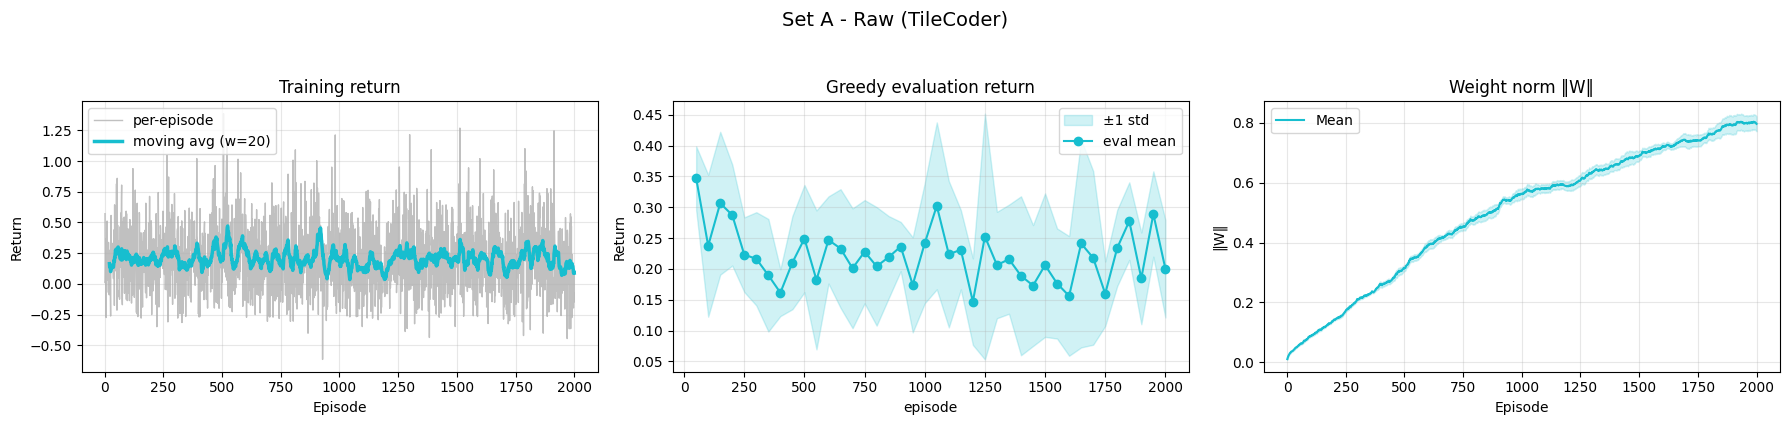

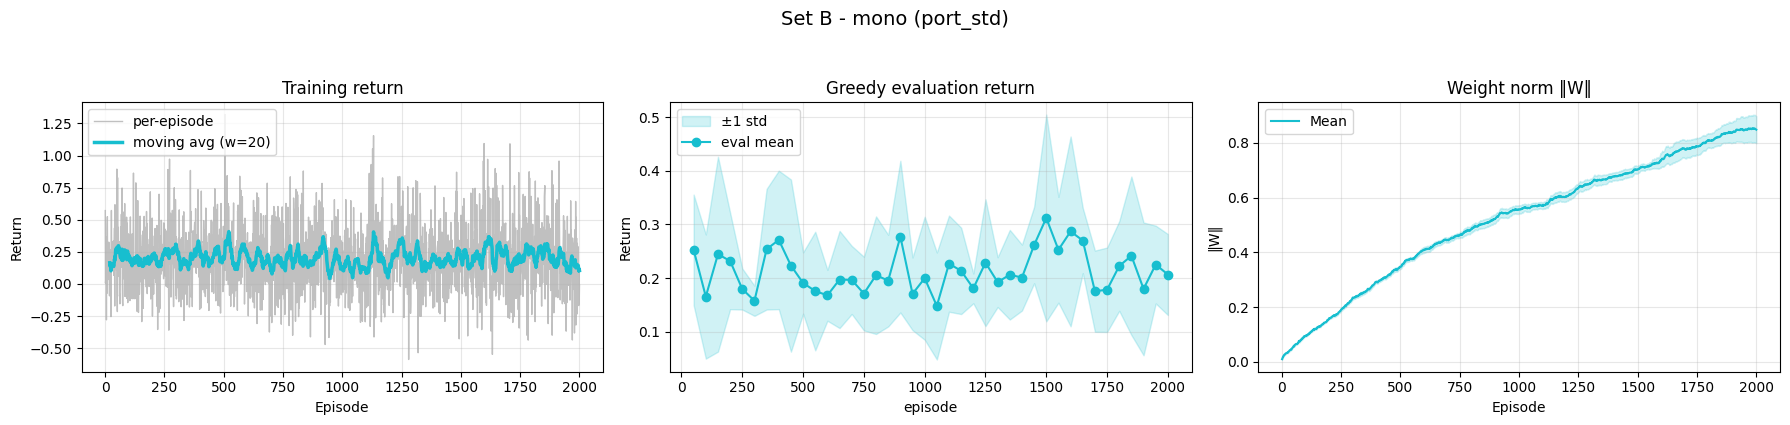

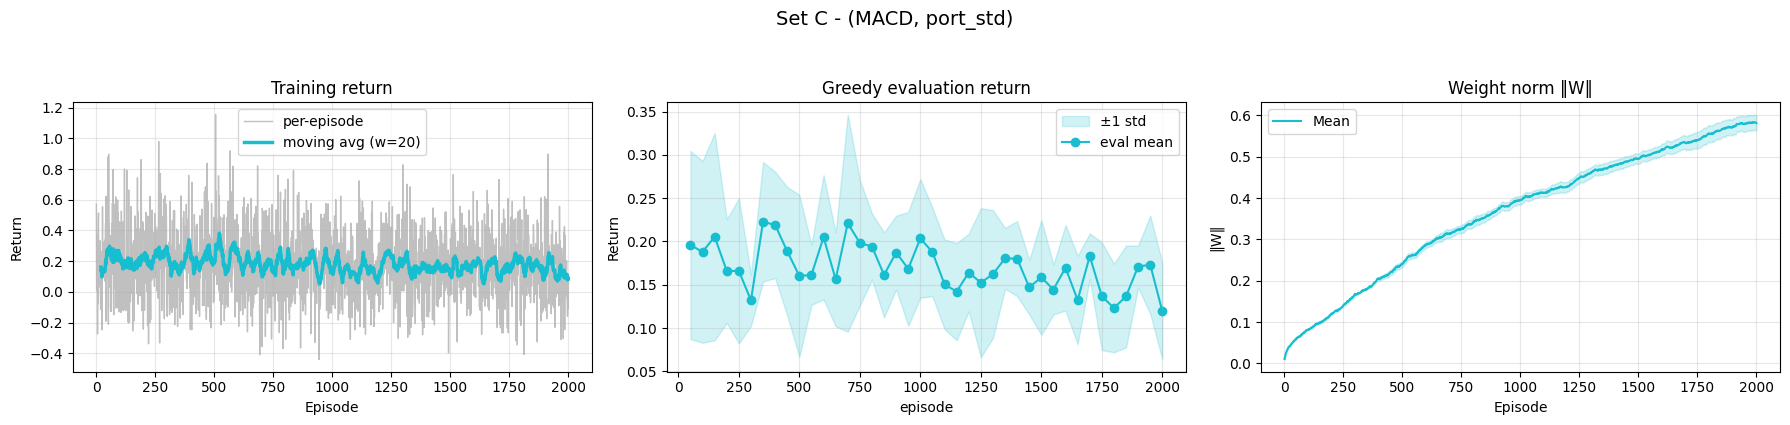

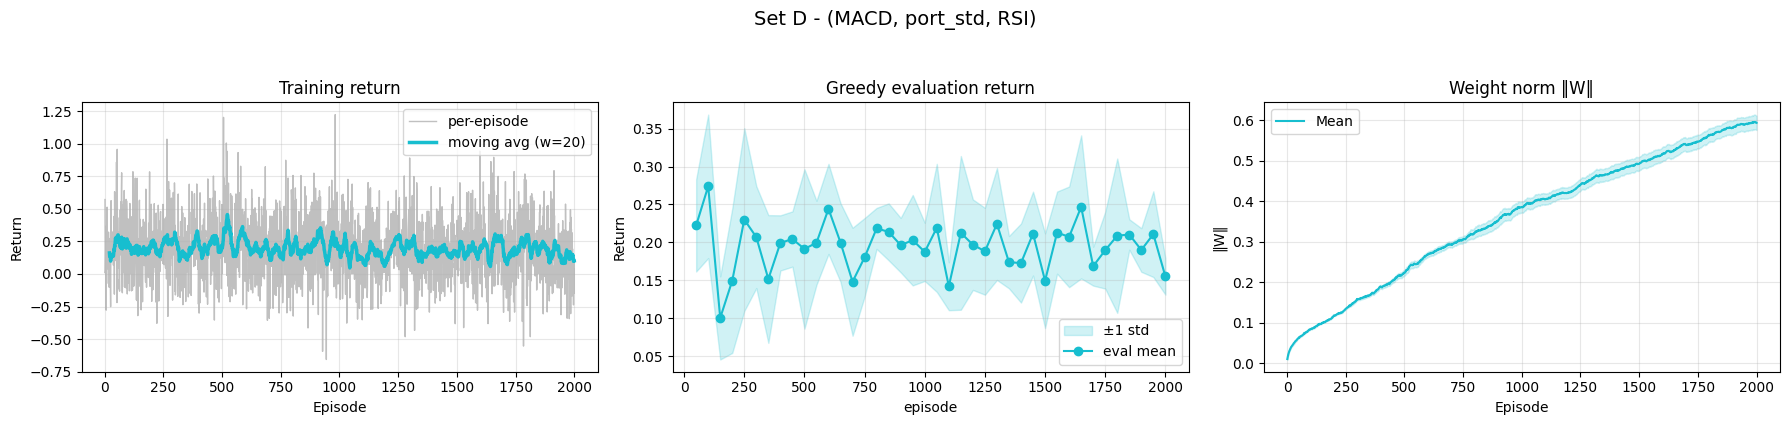

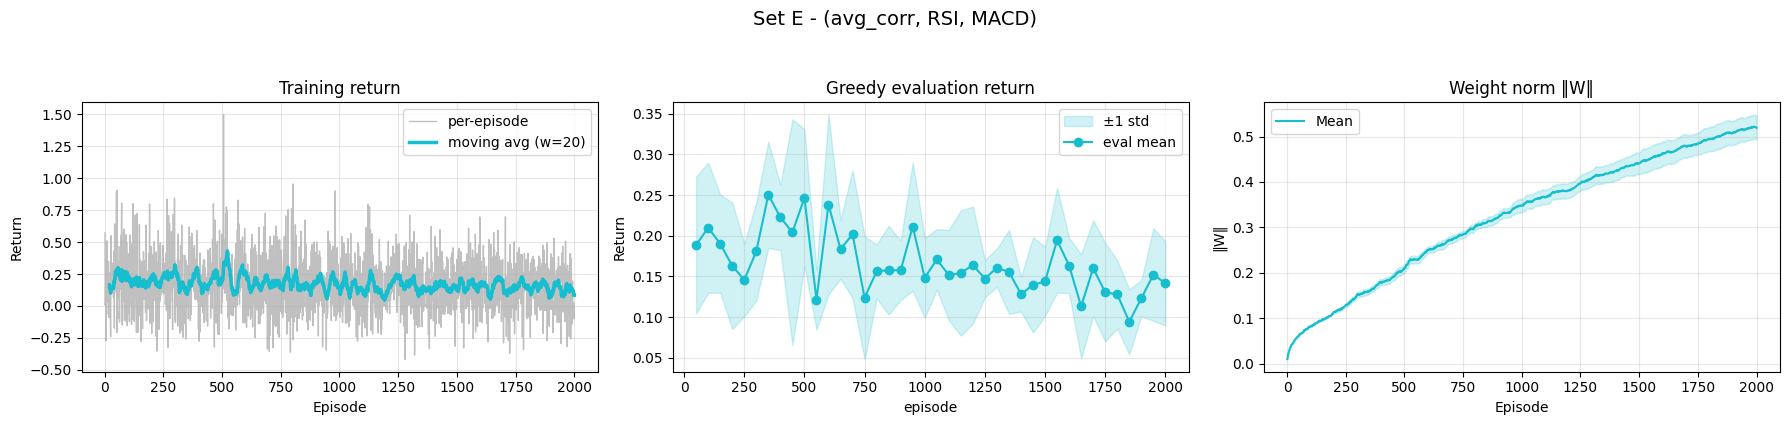

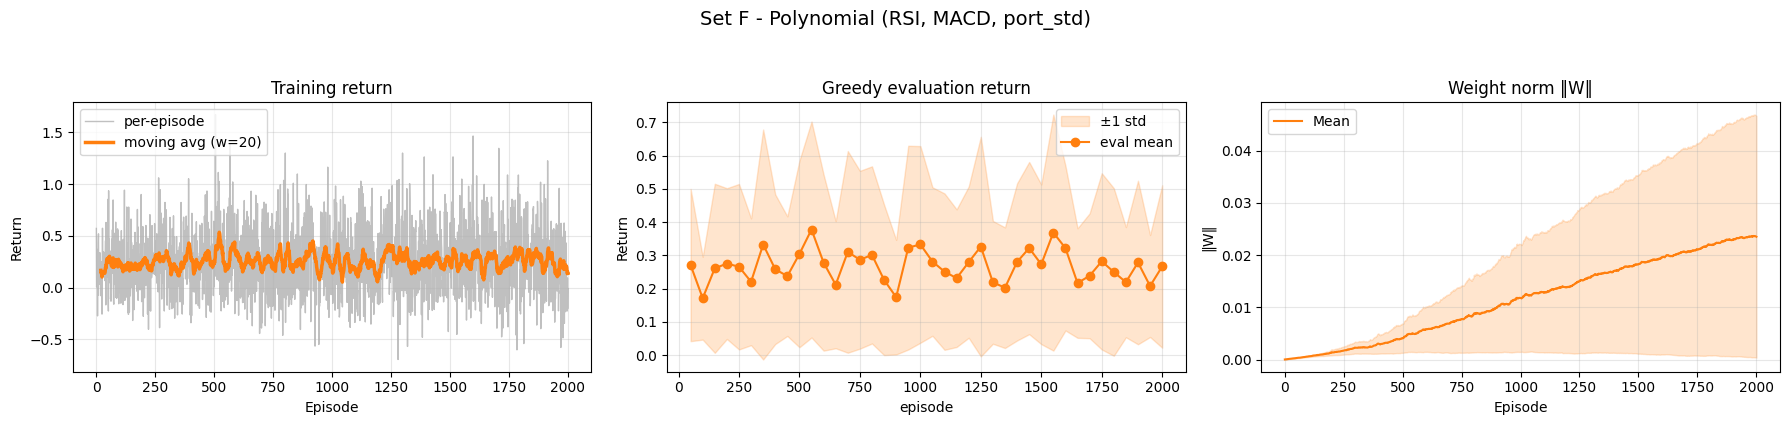

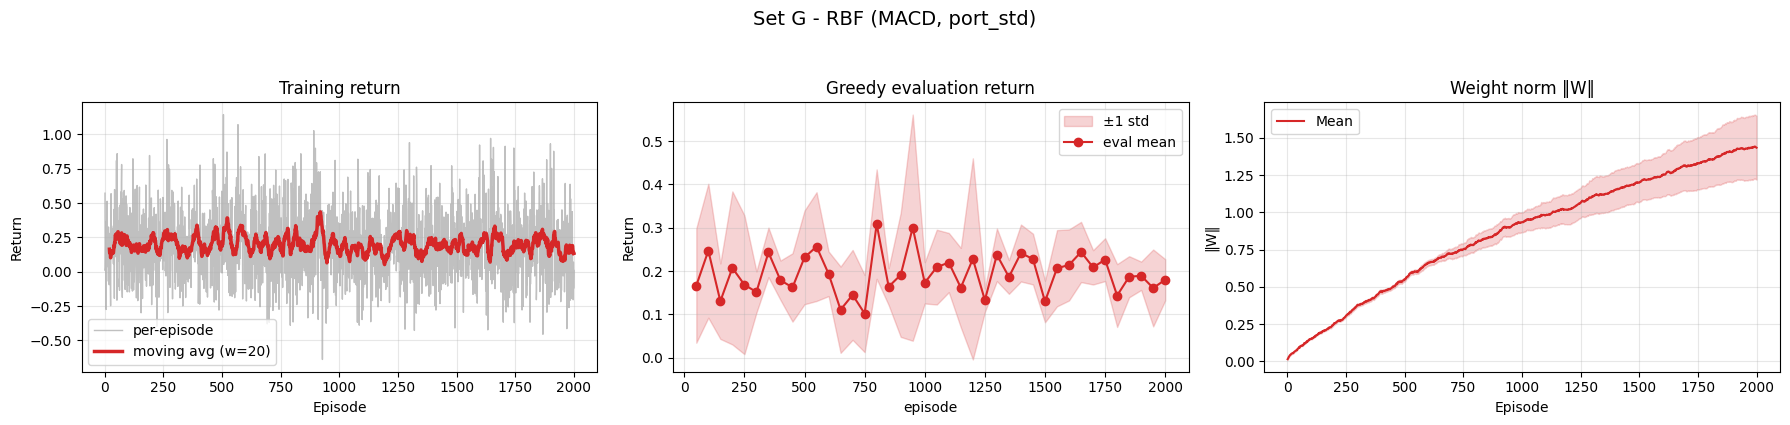

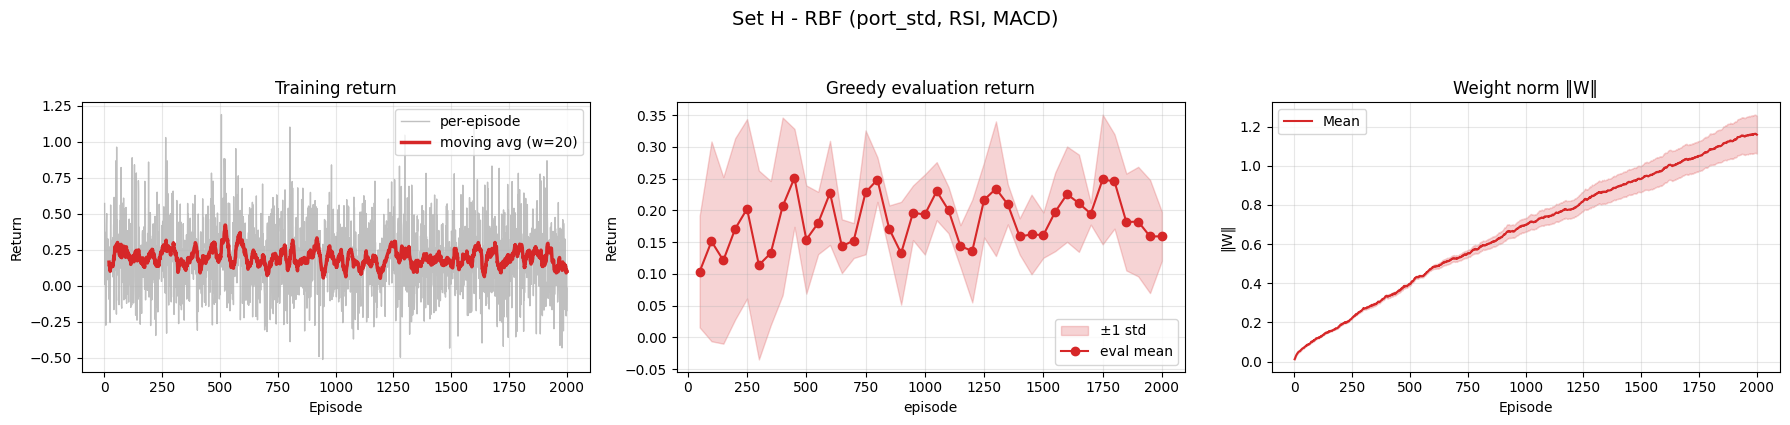

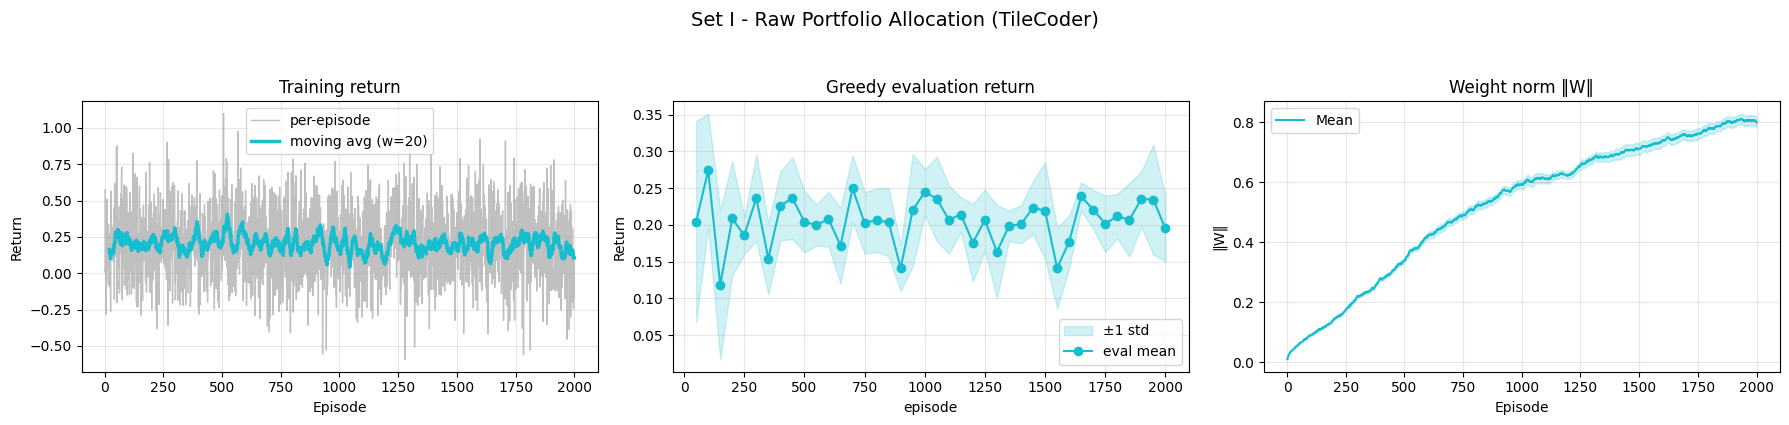

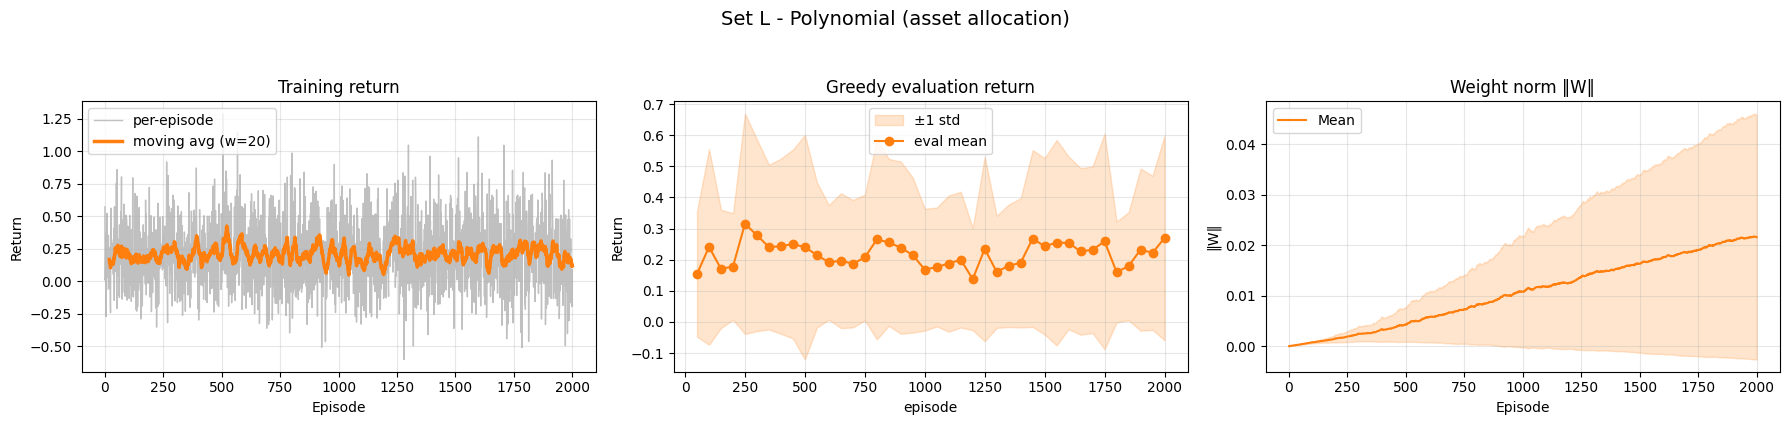

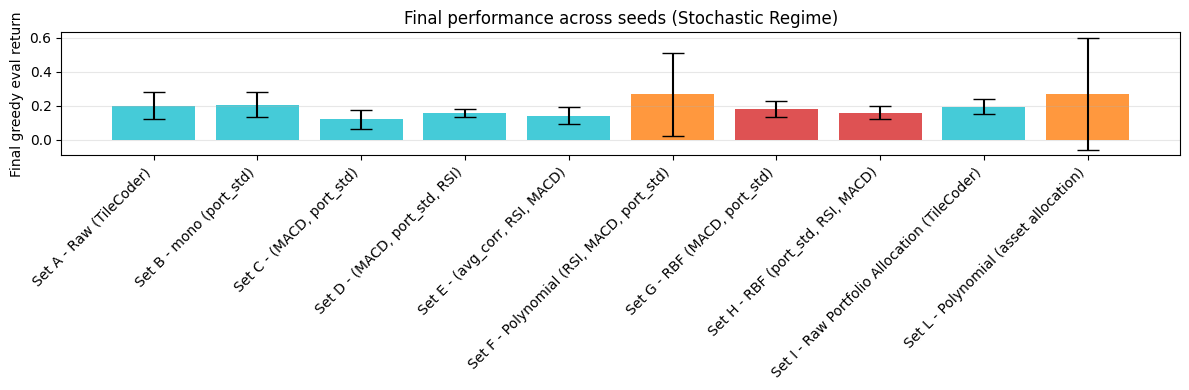

In [10]:
feature_sets_experiments = {
    'Set A - Raw (TileCoder)': {'features': feat_setA, 'alpha': TC_ALPHA, 'color': 'tab:cyan'},
    'Set B - mono (port_std)': {'features': feat_setB, 'alpha': TC_ALPHA, 'color': 'tab:cyan'},
    'Set C - (MACD, port_std)': {'features': feat_setC, 'alpha': TC_ALPHA, 'color': 'tab:cyan'},
    'Set D - (MACD, port_std, RSI)': {'features': feat_setD, 'alpha': TC_ALPHA, 'color': 'tab:cyan'},
    'Set E - (avg_corr, RSI, MACD)': {'features': feat_setE, 'alpha': TC_ALPHA, 'color': 'tab:cyan'},
    'Set F - Polynomial (RSI, MACD, port_std)': {'features': feat_set3, 'alpha': POLY_ALPHA, 'color': 'tab:orange'},
    'Set G - RBF (MACD, port_std)': {'features': feat_setG, 'alpha': RBF_ALPHA, 'color': 'tab:red'},
    'Set H - RBF (port_std, RSI, MACD)': {'features': feat_set2, 'alpha': RBF_ALPHA, 'color': 'tab:red'},
    'Set I - Raw Portfolio Allocation (TileCoder)': {'features': feat_setI, 'alpha': TC_ALPHA, 'color': 'tab:cyan'},
    'Set L - Polynomial (asset allocation)': {'features': feat_setL, 'alpha': TC_ALPHA, 'color': 'tab:orange'}
}

result_dir = "stoch_regime__20260723_232829"
final_evals = MarketCharts.plot_training_trajectories(feature_sets_experiments, result_dir)
MarketCharts.plot_final_performance(final_evals, feature_sets_experiments)

## 7. Greedy rollout

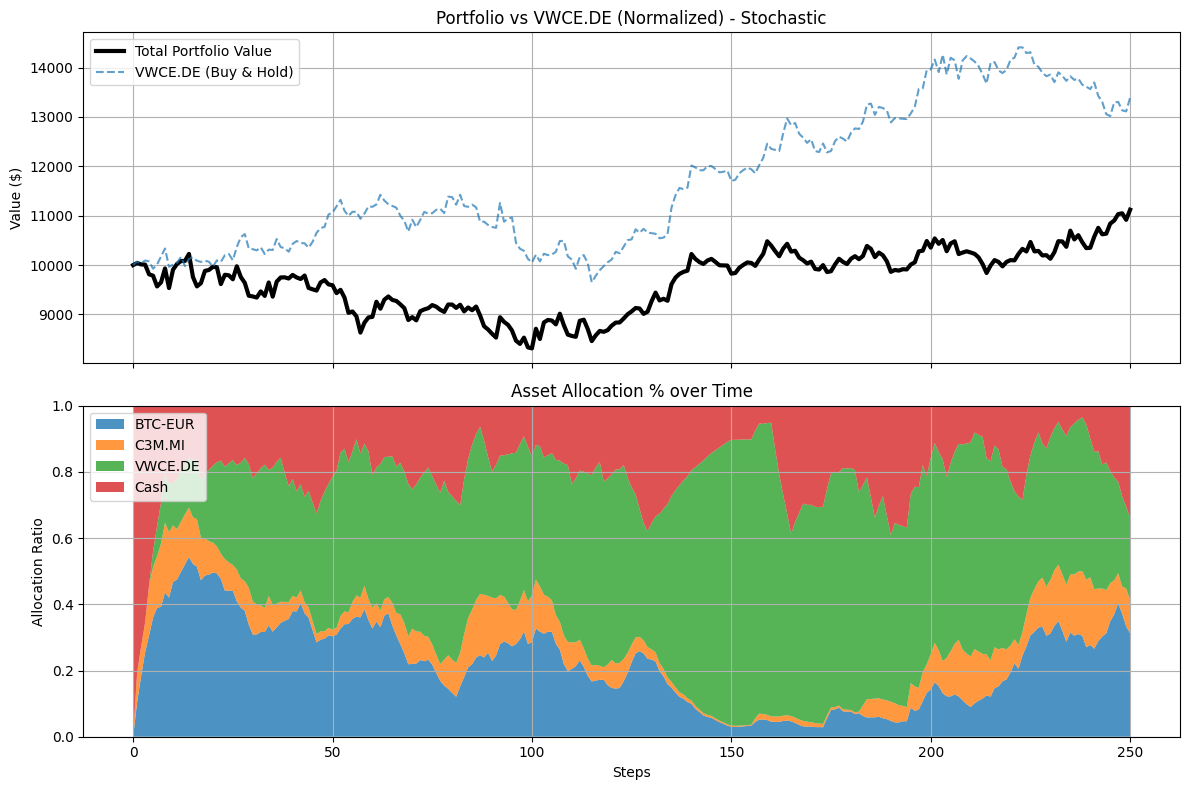

In [11]:
def render_rollout(label, agent):
    env_eval = make_env_stochastic()
    agent.epsilon = 0.0
    obs, _ = env_eval.reset(seed=MASTER_SEED)
    for step in range(250):
        a_flat = agent.select_action(obs, greedy=True)
        obs, _, _, _, _ = env_eval.step(a_flat)
        if step % 5 == 0:
            env_eval.render(benchmark_asset=BENCHMARK_ASSET)
            time.sleep(0.05)
    env_eval.render(benchmark_asset=BENCHMARK_ASSET)
    return env_eval

label, feat, alpha = feature_sets[0]  
agent = trained_agents[label][0]
render_rollout(label, agent)

## Visualising the Value Function Structure (2D Heatmaps)

To show the relationship between feature design and the structure of the value function, we visualise the Q-value surface for the **Hold** action across a 2D grid of **MACD** and **port_std**. All other state variables are held constant.

Quickly training agents to populate weights for visualization...


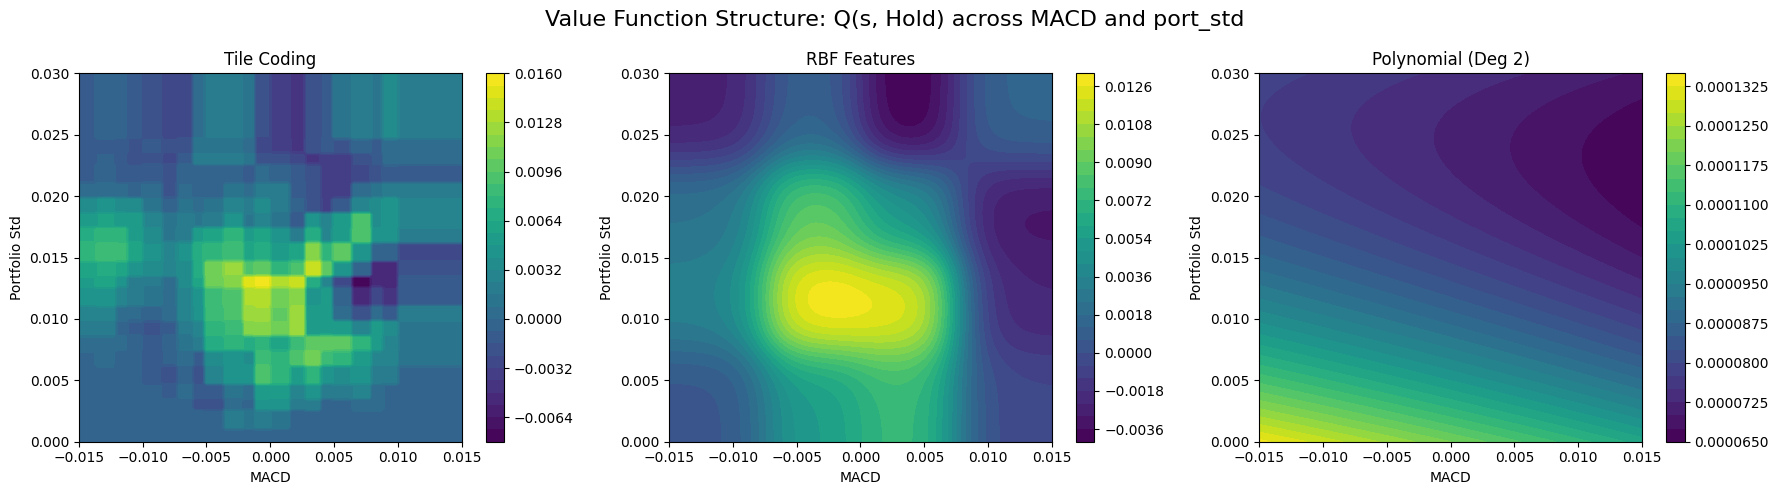

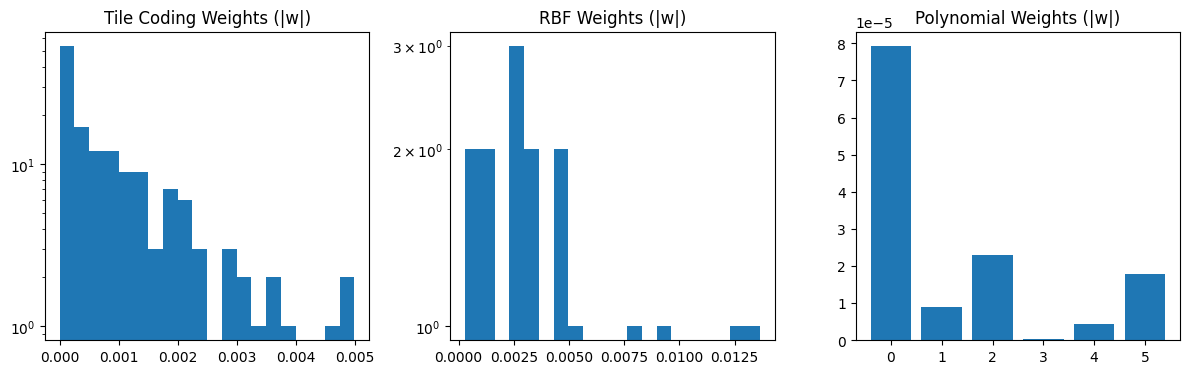

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from agents.linear_sarsa import LinearSARSAAgent
from utils.features import TileCoder, RBFFeatures, PolynomialFeatures
from utils.training import train
env_viz = make_env_stochastic()
MACD_IDX = 10
PORT_STD_IDX = 9

feat_tc = TileCoder(
    low=np.array([-0.015,0]),
    high=np.array([0.015,0.03]),
    n_tiles=[6,6],
    n_tilings=4,
    feature_indices=[MACD_IDX, PORT_STD_IDX],
)

feat_rbf = RBFFeatures(
    low=np.array([-0.015,0]),
    high=np.array([0.015,0.03]),
    n_centers=[4,4],
    sigma=RBF_SIGMA,
    normalize=True,
    feature_indices=[MACD_IDX, PORT_STD_IDX]
)

feat_poly = PolynomialFeatures(
    state_dim=11, degree=2,
    feature_indices=[MACD_IDX, PORT_STD_IDX],
    low=np.array([-0.015,0]),
    high=np.array([0.015, 0.03])
)

agents = {
    "Tile Coding": LinearSARSAAgent(feature_extractor=feat_tc, n_actions=env_viz.action_space.n, alpha=NOMINAL_ALPHA / TC_N_TILINGS),
    "RBF Features": LinearSARSAAgent(feature_extractor=feat_rbf, n_actions=env_viz.action_space.n, alpha=NOMINAL_ALPHA),
    "Polynomial (Deg 2)": LinearSARSAAgent(feature_extractor=feat_poly, n_actions=env_viz.action_space.n, alpha=POLY_ALPHA)
}

print("Quickly training agents to populate weights for visualization...")
for name, agent in agents.items():
    train(agent, env_viz, n_episodes=100, max_steps_per_episode=250, progress=False)

# Setup 2D Grid
macd_vals = np.linspace(-0.015, 0.015, 100)
port_std_vals = np.linspace(0, 0.03, 100)
MACD, PORT_STD = np.meshgrid(macd_vals, port_std_vals)

base_state = env_viz.reset()[0]
HOLD_ACTION = 13  # Hold all assets

MarketCharts.plot_value_function_heatmaps(agents, base_state, MACD_IDX, PORT_STD_IDX)
MarketCharts.plot_weight_sparsity(agents)

## State visitation and action choice

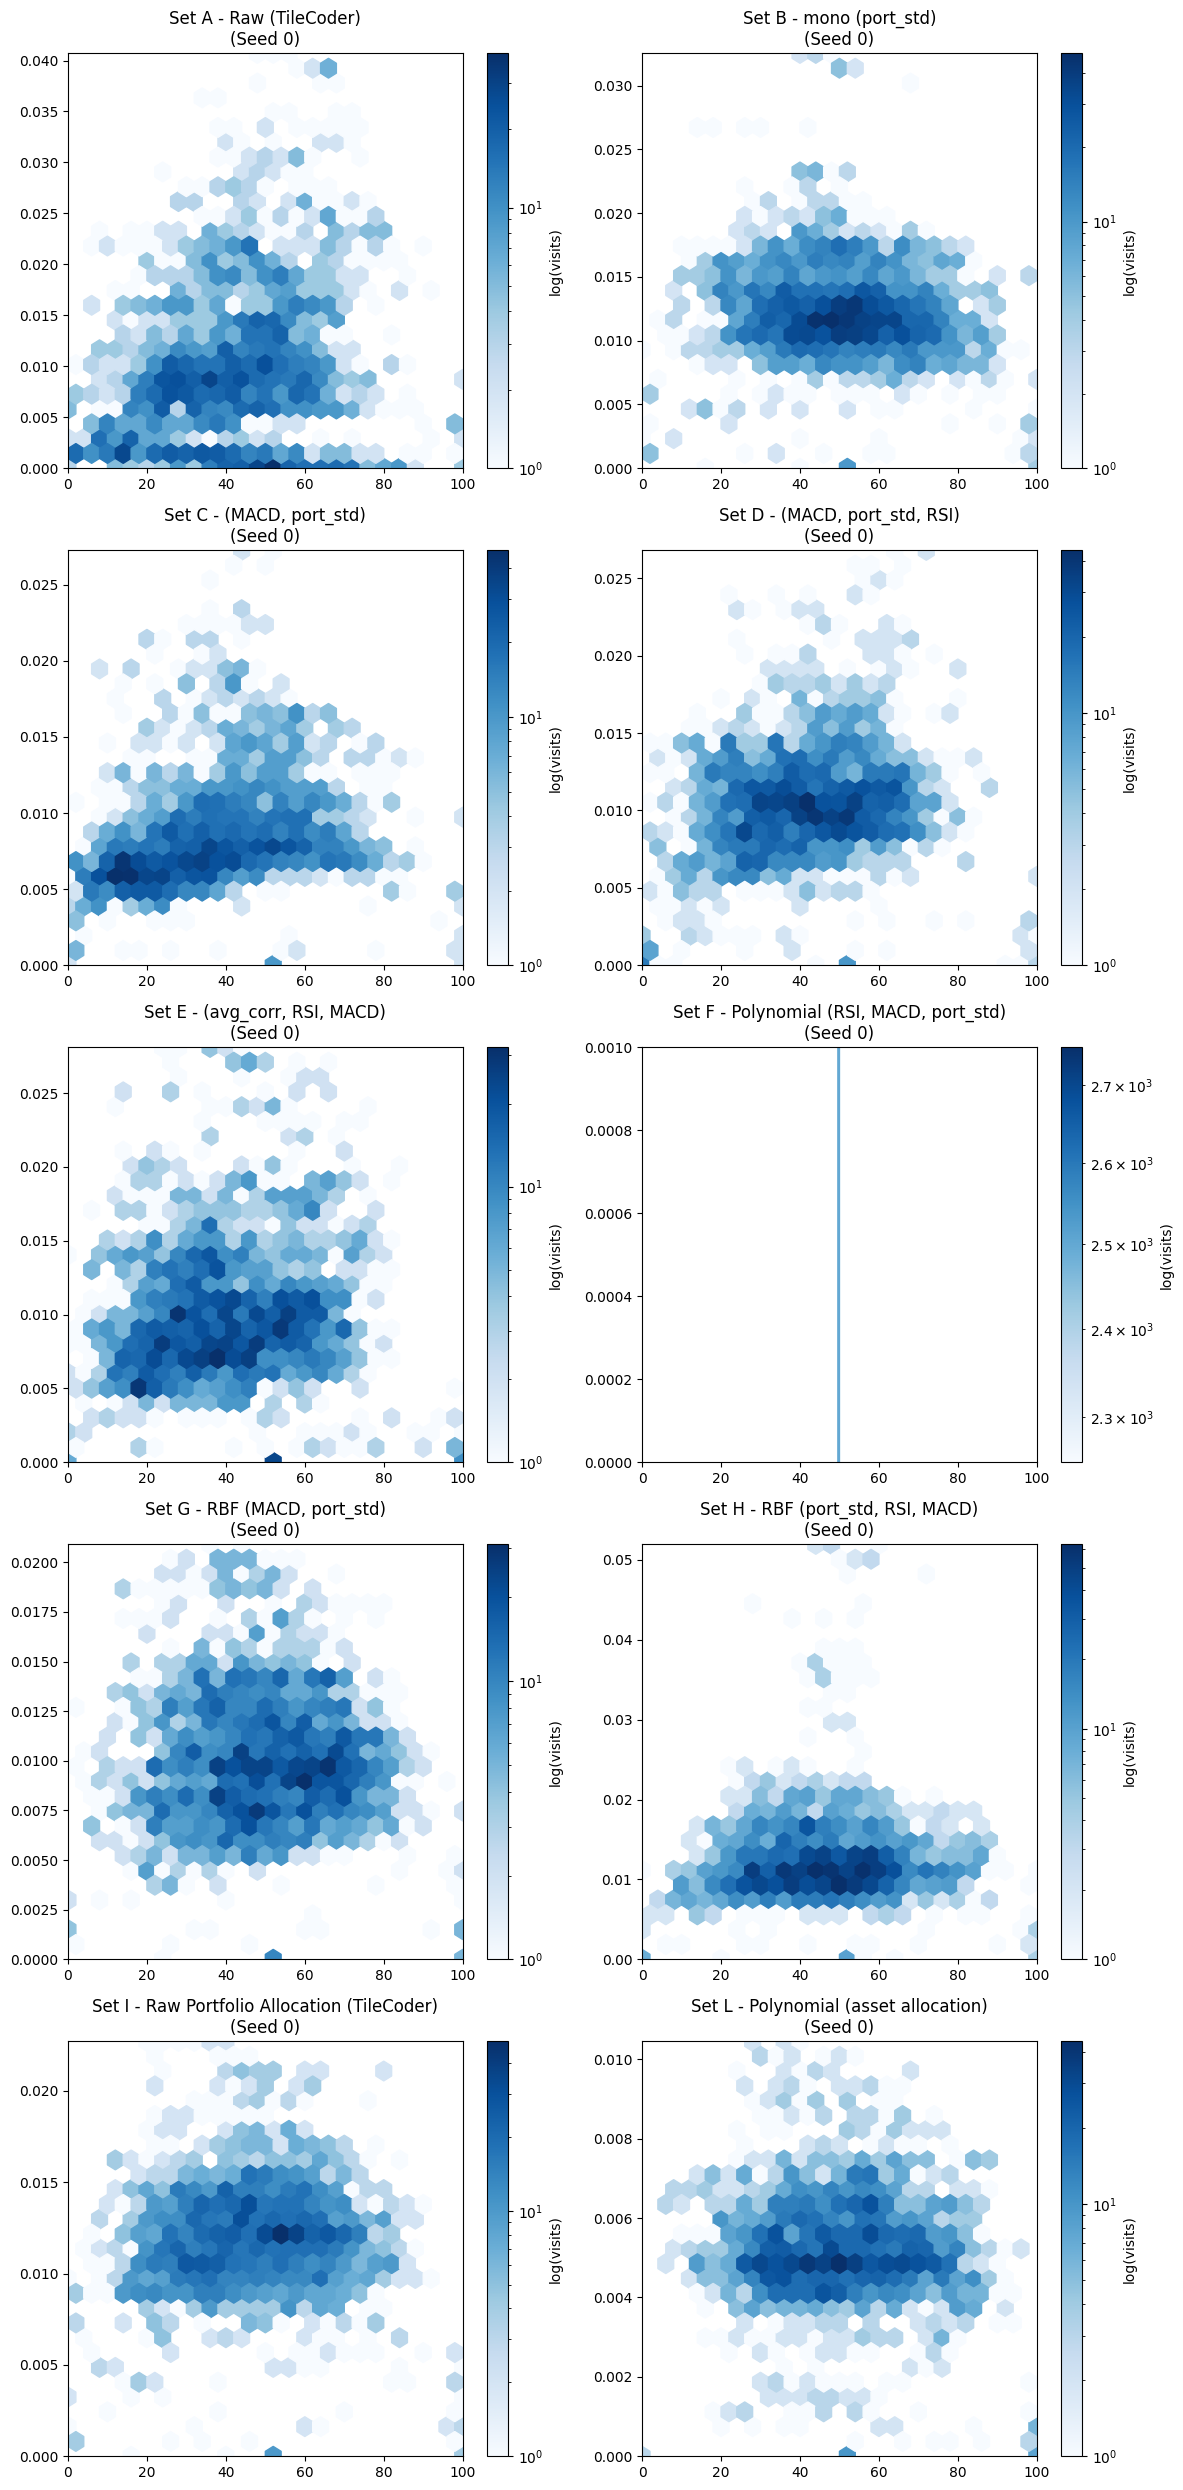


=== Top 5 Most Used Actions per Agent ===

Agent: Set A - Raw (TileCoder)
Action ID   Description (Asset 0/1/2)     Count     % of Total
-----------------------------------------------------------------
12          Sell / Hold / Hold            442        17.7%
24          Sell / Buy / Buy              261        10.4%
3           Sell / Hold / Sell            246         9.8%
21          Sell / Hold / Buy             215         8.6%
4           Hold / Hold / Sell            164         6.6%

Agent: Set B - mono (port_std)
Action ID   Description (Asset 0/1/2)     Count     % of Total
-----------------------------------------------------------------
11          Buy / Sell / Hold             1138       45.5%
22          Hold / Hold / Buy             459        18.4%
18          Sell / Sell / Buy             443        17.7%
23          Buy / Hold / Buy              282        11.3%
14          Buy / Hold / Hold             57          2.3%

Agent: Set C - (MACD, port_std)
Action ID   

In [14]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from experiments.feature_configs import _safe_name
from envs.market import MarketEnv
from agents.linear_sarsa import LinearSARSAAgent
from utils.features import TileCoder, RBFFeatures, PolynomialFeatures

result_dir = "stoch_regime__20260723_232829"

MarketCharts.plot_state_visitation_and_actions(
    feature_sets_experiments, result_dir, 
    make_env_stochastic, LinearSARSAAgent, 
    TileCoder, RBFFeatures, PolynomialFeatures,
    TC_N_TILINGS, RBF_SIGMA, MASTER_SEED
)

Loaded 30 runs across 10 configs


,mean,std,count
config,,,
Set L - Polynomial (asset allocation),0.283715,0.431671,3
Set I - Raw Portfolio Allocation (TileCoder),0.229559,0.055745,3
Set B - mono (port_std),0.182507,0.066960,3
"Set F - Polynomial (RSI, MACD, port_std)",0.176483,0.284454,3
"Set D - (MACD, port_std, RSI)",0.173652,0.064517,3
"Set E - (avg_corr, RSI, MACD)",0.164219,0.024043,3
Set A - Raw (TileCoder),0.161617,0.029016,3
"Set H - RBF (port_std, RSI, MACD)",0.149580,0.026675,3
"Set G - RBF (MACD, port_std)",0.136713,0.007325,3


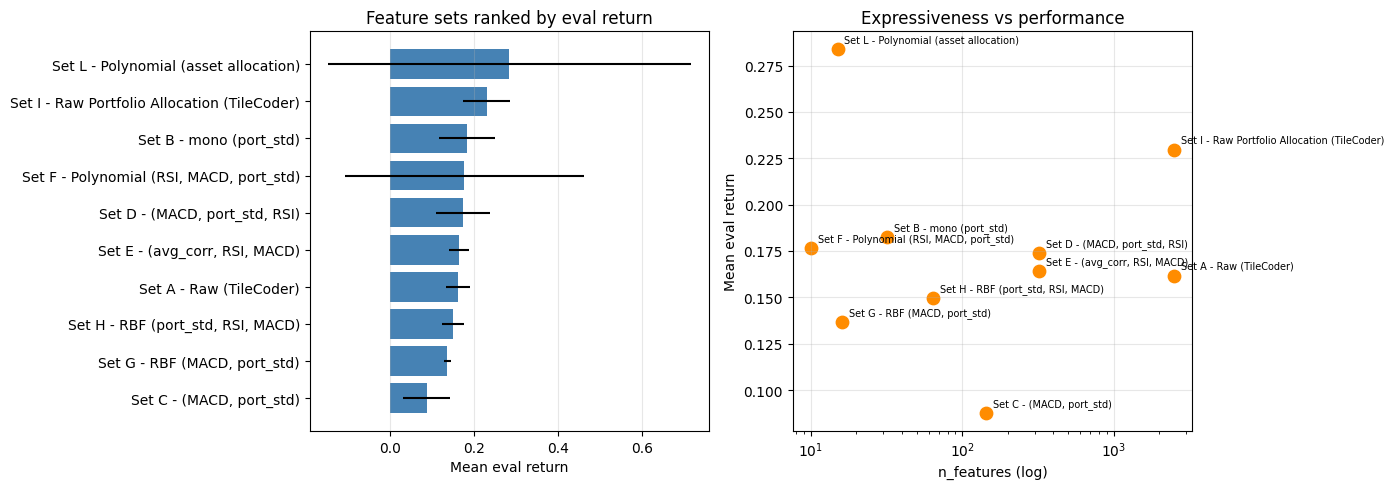

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from experiments.feature_configs import load_results, summarize

df = load_results("results/feature_sweep__stoch_regime__20260723_230515.csv")
MarketCharts.plot_feature_sweep_results(df)

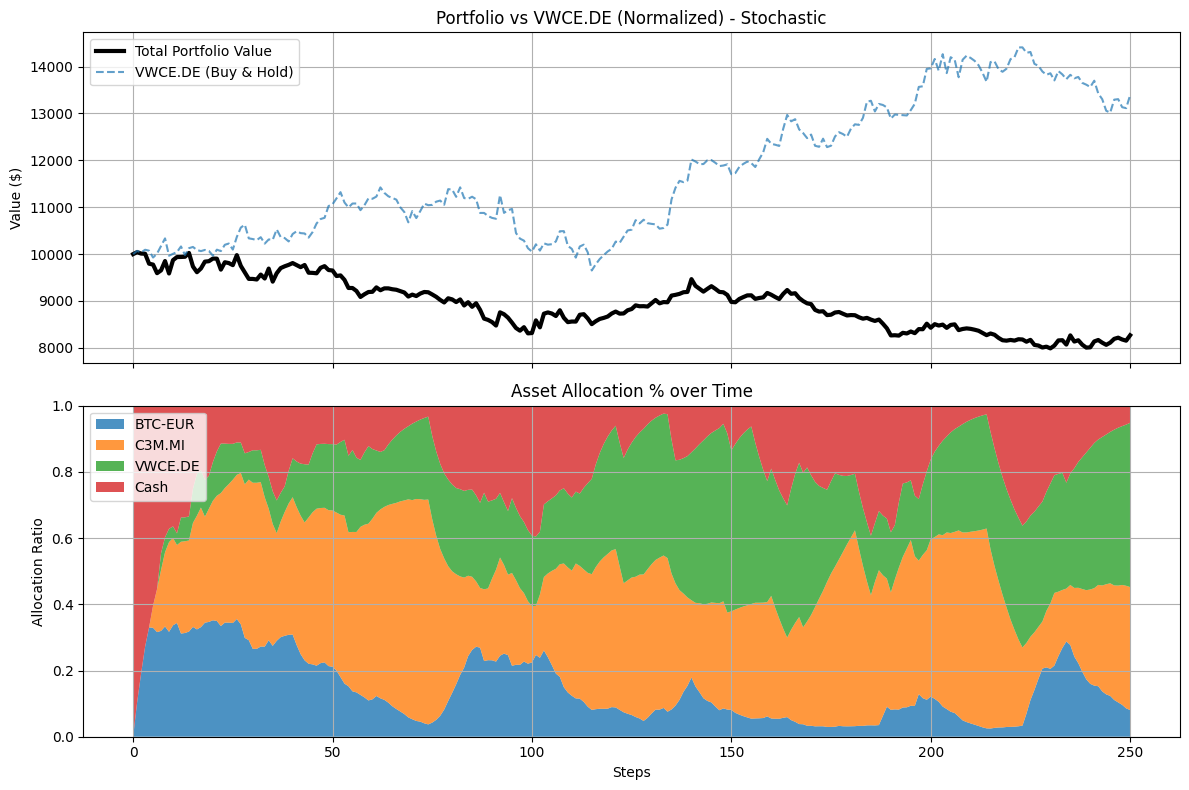

In [19]:
import numpy as np
import glob
from experiments.feature_configs import _safe_name


result_dir = "stoch_regime__20260723_230515"  

config_info = next(c for name, c in feature_sets_experiments.items() if "Set C" in name)
label = "Set C - (MACD, port_std)"
feat = config_info['features']
safe_label = _safe_name(label)

files = glob.glob(f"results/histories/{result_dir}/{safe_label}__seed0.npz")

if not files:
    print(f"Could not find npz file for {label}")
else:
    data = np.load(files[0])
    
    if "weights" not in data:
        print("This .npz file does not contain saved weights!")
    else:
        s = 0  # Seed 0
        if isinstance(feat, TileCoder):
            f = TileCoder(low=feat.low, high=feat.high, n_tiles=feat.n_tiles, n_tilings=TC_N_TILINGS, feature_indices=feat.feature_indices, seed=s)
        elif isinstance(feat, RBFFeatures):
            f = RBFFeatures(low=feat.low, high=feat.high, n_centers=feat.n_centers, sigma=RBF_SIGMA, normalize=True, feature_indices=feat.feature_indices)
        else:
            f = PolynomialFeatures(state_dim=11, degree=2, feature_indices=feat.feature_indices, low=feat.low, high=feat.high)

        env_eval = make_env_stochastic()
        agent = LinearSARSAAgent(
            n_actions=env_eval.action_space.n,
            feature_extractor=f,
            alpha=0.01,
            seed=s
        )
        
        agent.W = data["weights"]
        
        # Render the rollout
        print(f"Rendering: {label}")
        render_rollout(f"Loaded: {label}", agent)